# Baseline clásico para Flotation Froth Sequence Images

- Dorian Ticona

In [ ]:
!pip -q install scikit-image seaborn tqdm

In [ ]:
import os
import re
import zipfile
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

Imports OK


## 1. Montar Google Drive y resolver ruta del dataset

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print('No parece ser Colab o Drive ya está montado:', e)

Mounted at /content/drive


In [ ]:
DRIVE_ROOT = Path('/content/drive/MyDrive') if Path('/content/drive/MyDrive').exists() else Path.cwd()

DATASET_ROOT = DRIVE_ROOT / 'Amta_lab' / 'datasets' / 'Dataset: "Flotation Froth Sequence Images"'

if DATASET_ROOT is None:
    print('No se encontró automáticamente. Candidatos revisados:')
    for p in candidate_paths:
        print(' -', p)
    raise FileNotFoundError('Seteá DATASET_ROOT manualmente con la ruta real del dataset en Drive.')

print('DATASET_ROOT =', DATASET_ROOT)
print('Contenido inicial:')
for x in sorted(DATASET_ROOT.iterdir())[:20]:
    print(' -', x.name)

DATASET_ROOT = /content/drive/MyDrive/Amta_lab/datasets/Dataset: "Flotation Froth Sequence Images"
Contenido inicial:
 - class Ⅰ.zip
 - class Ⅱ.zip
 - class Ⅲ.zip
 - class Ⅳ.zip


## 2. Preparar dataset: extraído o ZIPs

Si los ZIPs están en Drive y no están extraídos, se extraen a almacenamiento temporal de Colab para no ensuciar Drive.

In [ ]:
WORK_DIR = Path('/content/drn_flotation_froth_sequence_work') if IN_COLAB else Path.cwd() / 'drn_flotation_froth_sequence_work'
EXTRACT_DIR = WORK_DIR / 'extracted'
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

zip_files = sorted(DATASET_ROOT.glob('*.zip'))

if zip_files:
    print(f'Se encontraron {len(zip_files)} ZIPs. Extrayendo/reutilizando en: {EXTRACT_DIR}')
    for z in zip_files:
        target = EXTRACT_DIR / z.stem
        if target.exists() and any(target.iterdir()):
            print('Ya extraído:', z.name)
            continue
        target.mkdir(parents=True, exist_ok=True)
        print('Extrayendo:', z.name)
        with zipfile.ZipFile(z, 'r') as zip_ref:
            zip_ref.extractall(target)
    DATA_ROOT = EXTRACT_DIR
else:
    print('No se encontraron ZIPs. Asumo dataset ya extraído.')
    DATA_ROOT = DATASET_ROOT

print('DATA_ROOT =', DATA_ROOT)
for x in sorted(DATA_ROOT.iterdir())[:20]:
    print(' -', x.name)

Se encontraron 4 ZIPs. Extrayendo/reutilizando en: /content/drn_flotation_froth_sequence_work/extracted
Extrayendo: class Ⅰ.zip
Extrayendo: class Ⅱ.zip
Extrayendo: class Ⅲ.zip
Extrayendo: class Ⅳ.zip
DATA_ROOT = /content/drn_flotation_froth_sequence_work/extracted
 - class Ⅰ
 - class Ⅱ
 - class Ⅲ
 - class Ⅳ


## 3. Indexar secuencias

Cada fila del índice representa una secuencia de frames con su clase.

In [ ]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def normalize_label(name: str) -> str:
    s = name.strip()
    s = s.replace('Ⅰ', 'I').replace('Ⅱ', 'II').replace('Ⅲ', 'III').replace('Ⅳ', 'IV')
    s = re.sub(r'[_\-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

def image_files_in_dir(d: Path):
    return sorted([p for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

def find_sequence_dirs(class_dir: Path):
    seq_dirs = []
    for d in class_dir.rglob('*'):
        if d.is_dir() and len(image_files_in_dir(d)) >= 2:
            seq_dirs.append(d)
    if not seq_dirs and len(image_files_in_dir(class_dir)) >= 2:
        seq_dirs = [class_dir]
    return sorted(set(seq_dirs))

first_level_dirs = [p for p in DATA_ROOT.iterdir() if p.is_dir()]
class_dirs = [p for p in first_level_dirs if re.search(r'class|Ⅰ|Ⅱ|Ⅲ|Ⅳ|\bI{1,3}V?\b', p.name, re.IGNORECASE)]

if len(class_dirs) == 0 and len(first_level_dirs) == 1:
    nested = first_level_dirs[0]
    maybe = [p for p in nested.iterdir() if p.is_dir() and re.search(r'class|Ⅰ|Ⅱ|Ⅲ|Ⅳ|\bI{1,3}V?\b', p.name, re.IGNORECASE)]
    if maybe:
        DATA_ROOT = nested
        class_dirs = maybe

if not class_dirs:
    class_dirs = first_level_dirs

print('Carpetas de clase detectadas:')
for c in sorted(class_dirs):
    print(' -', c.name)

rows = []
for class_dir in sorted(class_dirs):
    label = normalize_label(class_dir.name)
    for seq_dir in find_sequence_dirs(class_dir):
        frames = image_files_in_dir(seq_dir)
        if len(frames) < 2:
            continue
        rows.append({
            'sequence_id': f'{label}__{seq_dir.name}',
            'label': label,
            'sequence_dir': str(seq_dir),
            'n_frames': len(frames),
            'frame_paths': [str(p) for p in frames],
        })

index_df = pd.DataFrame(rows)
print('Secuencias indexadas:', len(index_df))
if len(index_df):
    display(index_df.head())
    print('Distribución por clase:', Counter(index_df['label']))
else:
    raise RuntimeError('No se encontraron secuencias. Revisá la estructura del dataset.')

Carpetas de clase detectadas:
 - class Ⅰ
 - class Ⅱ
 - class Ⅲ
 - class Ⅳ
Secuencias indexadas: 2386


,sequence_id,label,sequence_dir,n_frames,frame_paths
0,class I__1001,class I,/content/drn_flotation_froth_sequence_work/ext...,12,[/content/drn_flotation_froth_sequence_work/ex...
1,class I__1002,class I,/content/drn_flotation_froth_sequence_work/ext...,12,[/content/drn_flotation_froth_sequence_work/ex...
2,class I__1003,class I,/content/drn_flotation_froth_sequence_work/ext...,12,[/content/drn_flotation_froth_sequence_work/ex...
3,class I__1004,class I,/content/drn_flotation_froth_sequence_work/ext...,12,[/content/drn_flotation_froth_sequence_work/ex...
4,class I__1005,class I,/content/drn_flotation_froth_sequence_work/ext...,12,[/content/drn_flotation_froth_sequence_work/ex...


Distribución por clase: Counter({'class II': 696, 'class I': 660, 'class III': 625, 'class IV': 405})


## 4. Visualizar muestras por clase

Antes de modelar, MIRÁ los datos. Si no entendés qué ve el modelo, después no sabés interpretar errores.

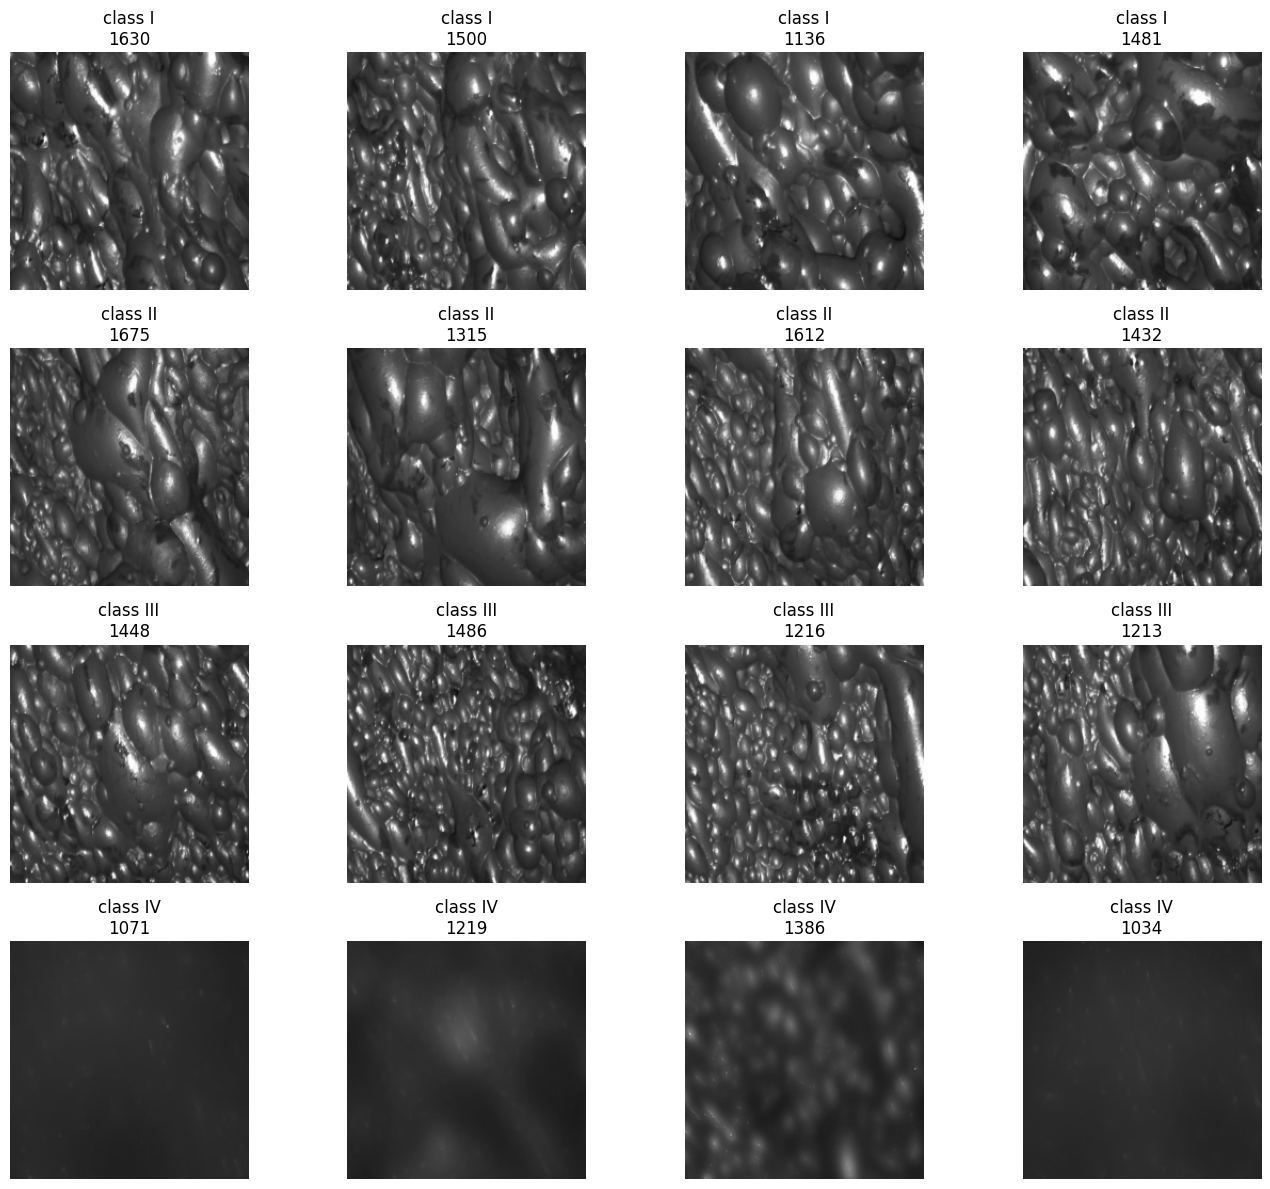

In [ ]:
def read_image_rgb(path, resize_to=None):
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f'No se pudo leer imagen: {path}')
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if resize_to is not None:
        img_rgb = cv2.resize(img_rgb, resize_to, interpolation=cv2.INTER_AREA)
    return img_rgb

labels = sorted(index_df['label'].unique())
fig, axes = plt.subplots(len(labels), 4, figsize=(14, 3 * len(labels)))
if len(labels) == 1:
    axes = np.array([axes])

for i, label in enumerate(labels):
    sample = index_df[index_df['label'] == label].sample(min(4, sum(index_df['label'] == label)), random_state=RANDOM_STATE)
    for j, (_, row) in enumerate(sample.iterrows()):
        frames = row['frame_paths']
        img = read_image_rgb(frames[len(frames)//2], resize_to=(224, 224))
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{label}\n{Path(row["sequence_dir"]).name}')
        axes[i, j].axis('off')
    for j in range(len(sample), 4):
        axes[i, j].axis('off')
plt.tight_layout()

## 5. Extracción de features clásicas

In [ ]:
RESIZE_TO = (224, 224)
LBP_POINTS = 24
LBP_RADIUS = 3
LBP_BINS = LBP_POINTS + 2

def color_features(img_rgb):
    feats = {}
    spaces = {
        'rgb': img_rgb,
        'hsv': cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV),
        'lab': cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB),
    }
    for space_name, arr in spaces.items():
        for ch in range(3):
            vals = arr[:, :, ch].astype(np.float32)
            feats[f'{space_name}_ch{ch}_mean'] = vals.mean()
            feats[f'{space_name}_ch{ch}_std'] = vals.std()
            feats[f'{space_name}_ch{ch}_p10'] = np.percentile(vals, 10)
            feats[f'{space_name}_ch{ch}_p90'] = np.percentile(vals, 90)
    return feats

def lbp_features(gray):
    lbp = local_binary_pattern(gray, P=LBP_POINTS, R=LBP_RADIUS, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_BINS + 1), range=(0, LBP_BINS), density=True)
    return {f'lbp_{i}': v for i, v in enumerate(hist)}

def glcm_features(gray):
    gray_small = (gray / 32).astype(np.uint8)
    glcm = graycomatrix(gray_small, distances=[1, 2, 4], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=8, symmetric=True, normed=True)
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    feats = {}
    for prop in props:
        vals = graycoprops(glcm, prop).ravel()
        feats[f'glcm_{prop}_mean'] = np.nanmean(vals)
        feats[f'glcm_{prop}_std'] = np.nanstd(vals)
    return feats

def edge_features(gray):
    edges = cv2.Canny(gray, 80, 160)
    return {'edge_density': float((edges > 0).mean()), 'gray_mean': float(gray.mean()), 'gray_std': float(gray.std())}

def temporal_features(frame_paths):
    grays = []
    for p in frame_paths:
        img = read_image_rgb(p, resize_to=RESIZE_TO)
        grays.append(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32))
    diffs = [np.abs(b - a).mean() for a, b in zip(grays[:-1], grays[1:])]
    diffs = np.array(diffs if diffs else [0.0], dtype=np.float32)
    return {'temporal_absdiff_mean': float(diffs.mean()), 'temporal_absdiff_std': float(diffs.std()), 'temporal_absdiff_max': float(diffs.max())}

def extract_sequence_features(row):
    frame_paths = row['frame_paths']
    img = read_image_rgb(frame_paths[len(frame_paths)//2], resize_to=RESIZE_TO)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    feats = {}
    feats.update(color_features(img))
    feats.update(lbp_features(gray))
    feats.update(glcm_features(gray))
    feats.update(edge_features(gray))
    feats.update(temporal_features(frame_paths))
    return feats

In [ ]:
FEATURES_CSV = WORK_DIR / 'drn_pipeline_a_features.csv'

if FEATURES_CSV.exists():
    print('Cargando features cacheadas:', FEATURES_CSV)
    features_df = pd.read_csv(FEATURES_CSV)
else:
    records = []
    for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc='Extrayendo features'):
        try:
            feats = extract_sequence_features(row)
            feats['sequence_id'] = row['sequence_id']
            feats['label'] = row['label']
            feats['sequence_dir'] = row['sequence_dir']
            feats['n_frames'] = row['n_frames']
            records.append(feats)
        except Exception as e:
            print('Error en', row['sequence_dir'], e)
    features_df = pd.DataFrame(records)
    features_df.to_csv(FEATURES_CSV, index=False)
    print('Features guardadas en:', FEATURES_CSV)

print(features_df.shape)
display(features_df.head())

Extrayendo features:   0%|          | 0/2386 [00:00<?, ?it/s]

Features guardadas en: /content/drn_flotation_froth_sequence_work/drn_pipeline_a_features.csv
(2386, 84)


,rgb_ch0_mean,rgb_ch0_std,rgb_ch0_p10,rgb_ch0_p90,rgb_ch1_mean,rgb_ch1_std,rgb_ch1_p10,rgb_ch1_p90,rgb_ch2_mean,rgb_ch2_std,...,edge_density,gray_mean,gray_std,temporal_absdiff_mean,temporal_absdiff_std,temporal_absdiff_max,sequence_id,label,sequence_dir,n_frames
0,73.186287,35.392082,43.0,110.0,73.186287,35.392082,43.0,110.0,73.186287,35.392082,...,0.082649,73.186284,35.392083,29.614882,1.439320,31.236767,class I__1001,class I,/content/drn_flotation_froth_sequence_work/ext...,12
1,75.036255,36.328716,44.0,118.0,75.036255,36.328716,44.0,118.0,75.036255,36.328716,...,0.085120,75.036252,36.328719,30.461372,1.221323,32.228676,class I__1002,class I,/content/drn_flotation_froth_sequence_work/ext...,12
2,68.532364,32.295967,42.0,105.0,68.532364,32.295967,42.0,105.0,68.532364,32.295967,...,0.109574,68.532366,32.295966,29.708168,1.776447,32.392918,class I__1003,class I,/content/drn_flotation_froth_sequence_work/ext...,12
3,71.462509,29.990192,46.0,105.0,71.462509,29.990192,46.0,105.0,71.462509,29.990192,...,0.107023,71.462512,29.990191,31.284655,2.287102,34.937618,class I__1004,class I,/content/drn_flotation_froth_sequence_work/ext...,12
4,68.973450,30.236816,43.0,104.0,68.973450,30.236816,43.0,104.0,68.973450,30.236816,...,0.103077,68.973453,30.236815,30.116295,1.383040,33.039242,class I__1005,class I,/content/drn_flotation_froth_sequence_work/ext...,12


## 6. Preparar matriz X/y

In [ ]:
meta_cols = ['sequence_id', 'label', 'sequence_dir']
feature_cols = [c for c in features_df.columns if c not in meta_cols]
X = features_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y = features_df['label']

print('X:', X.shape)
print('Clases:', Counter(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, Counter(y_train))
print('Test:', X_test.shape, Counter(y_test))

X: (2386, 81)
Clases: Counter({'class II': 696, 'class I': 660, 'class III': 625, 'class IV': 405})
Train: (1908, 81) Counter({'class II': 556, 'class I': 528, 'class III': 500, 'class IV': 324})
Test: (478, 81) Counter({'class II': 140, 'class I': 132, 'class III': 125, 'class IV': 81})


## 7. Entrenar modelos clásicos

In [ ]:
models = {
    'random_forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'svm_rbf': Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'))]),
    'knn': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    'pca_svm_rbf': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)), ('svc', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'))]),
}

results = []
fitted_models = {}
for name, model in models.items():
    print('\n===', name, '===')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    results.append({'model': name, 'accuracy': acc, 'macro_f1': f1})
    fitted_models[name] = model
    print('accuracy:', round(acc, 4), 'macro_f1:', round(f1, 4))
    print(classification_report(y_test, pred))

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
display(results_df)


=== random_forest ===
accuracy: 0.8326 macro_f1: 0.8459
              precision    recall  f1-score   support

     class I       0.82      0.92      0.87       132
    class II       0.77      0.79      0.78       140
   class III       0.80      0.67      0.73       125
    class IV       1.00      1.00      1.00        81

    accuracy                           0.83       478
   macro avg       0.85      0.85      0.85       478
weighted avg       0.83      0.83      0.83       478


=== svm_rbf ===
accuracy: 0.8661 macro_f1: 0.8771
              precision    recall  f1-score   support

     class I       0.84      0.95      0.89       132
    class II       0.83      0.82      0.83       140
   class III       0.84      0.74      0.79       125
    class IV       1.00      1.00      1.00        81

    accuracy                           0.87       478
   macro avg       0.88      0.88      0.88       478
weighted avg       0.87      0.87      0.86       478


=== knn ===
accuracy:

,model,accuracy,macro_f1
1,svm_rbf,0.866109,0.877083
0,random_forest,0.832636,0.845888
3,pca_svm_rbf,0.774059,0.791917
2,knn,0.757322,0.776029


## 8. Matriz de confusión del mejor modelo

Mejor modelo: svm_rbf


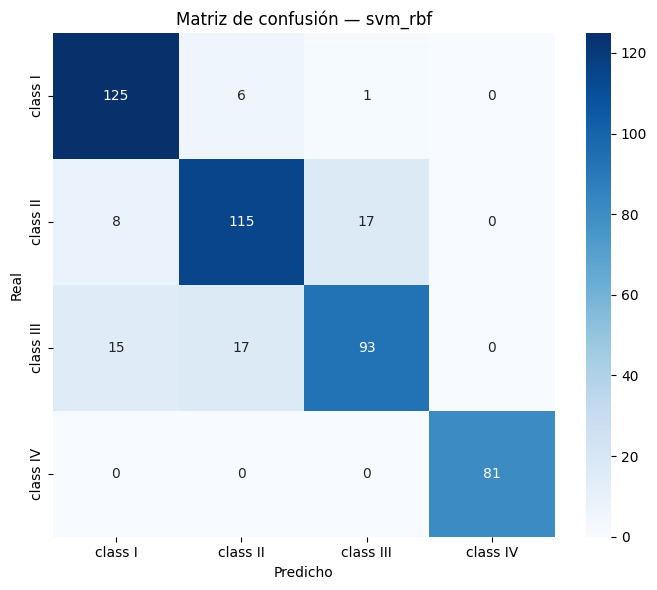

In [ ]:
best_name = results_df.iloc[0]['model']
best_model = fitted_models[best_name]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title(f'Matriz de confusión — {best_name}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
print('Mejor modelo:', best_name)

## 9. Importancia de features — Random Forest

,feature,importance
61,lbp_25,0.071713
74,edge_density,0.067164
64,glcm_dissimilarity_mean,0.047573
66,glcm_homogeneity_mean,0.041742
62,glcm_contrast_mean,0.039442
63,glcm_contrast_std,0.037548
36,lbp_0,0.036862
37,lbp_1,0.030969
59,lbp_23,0.027282
38,lbp_2,0.023168


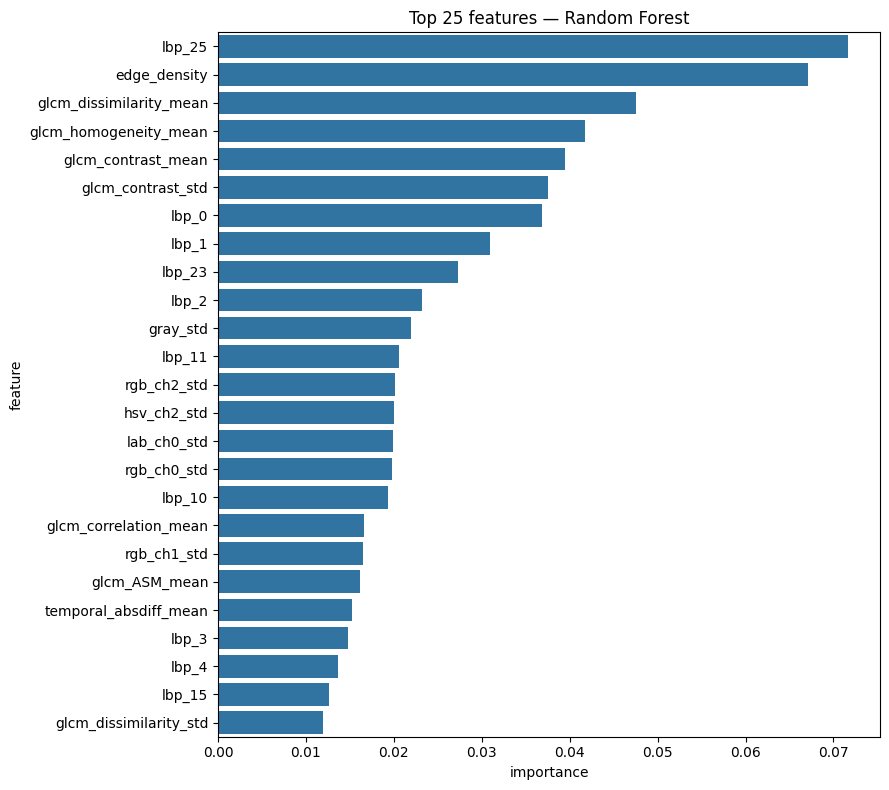

In [ ]:
rf = fitted_models.get('random_forest')
if rf is not None:
    importances = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
    display(importances.head(30))
    plt.figure(figsize=(9, 8))
    sns.barplot(data=importances.head(25), y='feature', x='importance')
    plt.title('Top 25 features — Random Forest')
    plt.tight_layout()

## 10. Validación cruzada rápida

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_rows.append({'model': name, 'cv_macro_f1_mean': scores.mean(), 'cv_macro_f1_std': scores.std()})
cv_df = pd.DataFrame(cv_rows).sort_values('cv_macro_f1_mean', ascending=False)
display(cv_df)

,model,cv_macro_f1_mean,cv_macro_f1_std
1,svm_rbf,0.846583,0.014126
0,random_forest,0.821668,0.011779
2,knn,0.776974,0.011591
3,pca_svm_rbf,0.774238,0.015554


## 11. Conclusiones

El baseline clásico funcionó bien y confirma que el dataset contiene señal visual útil para
distinguir las condiciones de flotación.

El mejor modelo fue:

- **SVM con kernel RBF**
- Accuracy: **0.8661**
- Macro-F1: **0.8771**

En validación cruzada también fue el mejor:

- CV Macro-F1 promedio: **0.8466**
- Desviación estándar: **0.0141**

Esto indica que el resultado no parece depender solamente de un split específico.

### Interpretación de la matriz de confusión

La clase con mejor separación fue **class IV**, con clasificación perfecta en el conjunto de prueba.

La **class I** también tuvo buen desempeño, con pocos errores.

Las principales confusiones ocurrieron entre:

- **class II - class III**
- **class III - class II**
- parcialmente **class III - class I**

Esto sugiere que las clases II y III tienen características visuales similares, probablemente en textura, bordes o
estructura de la espuma.

### Interpretación de features

Las features más importantes del Random Forest fueron principalmente:

- `lbp_*`
- `edge_density`
- `glcm_dissimilarity_mean`
- `glcm_homogeneity_mean`
- `glcm_contrast_mean`

Esto muestra que el modelo está usando sobre todo información de **textura, bordes y estructura de la espuma**, más
que color puro. Este resultado es coherente con la literatura revisada, donde la textura y la dinámica visual de la
espuma son señales fuertes para reconocer estados operacionales.